In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os

os.makedirs("reports", exist_ok=True)
os.makedirs("charts", exist_ok=True)

In [2]:
import os

# Set project path
os.chdir(r"C:\Users\nandi\OneDrive\Desktop\mutual_fund_analysis")

print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
C:\Users\nandi\OneDrive\Desktop\mutual_fund_analysis


In [3]:
import pandas as pd

nav = pd.read_csv(
    "data/processed/nav_history_clean.csv"
)

perf = pd.read_csv(
    "data/processed/scheme_performance_clean.csv"
)

tx = pd.read_csv(
    "data/processed/investor_transactions_clean.csv"
)

holdings = pd.read_csv(
    "data/processed/09_portfolio_holdings_clean.csv"
)

print("NAV:", nav.shape)
print("Performance:", perf.shape)
print("Transactions:", tx.shape)
print("Holdings:", holdings.shape)

NAV: (46000, 3)
Performance: (40, 19)
Transactions: (32778, 13)
Holdings: (322, 8)


In [4]:
nav["date"] = pd.to_datetime(
    nav["date"]
)

tx["transaction_date"] = pd.to_datetime(
    tx["transaction_date"]
)

print("Dates converted successfully.")

Dates converted successfully.


In [5]:
nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")
    ["nav"]
    .pct_change()
)

risk_results = []

for code in nav["amfi_code"].unique():

    ret = nav[
        nav["amfi_code"] == code
    ]["daily_return"].dropna()

    if len(ret) > 0:

        var95 = np.percentile(
            ret,
            5
        )

        cvar95 = ret[
            ret <= var95
        ].mean()

        risk_results.append([
            code,
            var95,
            cvar95
        ])

var_cvar = pd.DataFrame(
    risk_results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_cvar.to_csv(
    "reports/var_cvar_report.csv",
    index=False
)

var_cvar.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


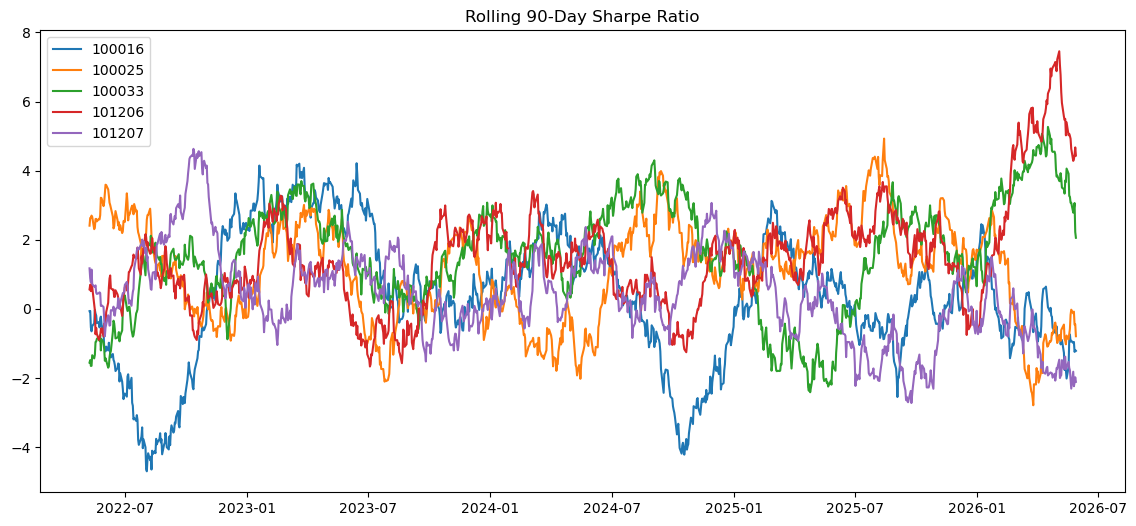

In [6]:
key_funds = nav[
    "amfi_code"
].unique()[:5]

plt.figure(figsize=(14,6))

for code in key_funds:

    temp = nav[
        nav["amfi_code"] == code
    ].copy()

    ret = temp[
        "daily_return"
    ]

    rolling_sharpe = (
        ret.rolling(90).mean()
        /
        ret.rolling(90).std()
    ) * np.sqrt(252)

    plt.plot(
        temp["date"],
        rolling_sharpe,
        label=str(code)
    )

plt.legend()

plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.savefig(
    "charts/rolling_sharpe_chart.png"
)

plt.show()

In [7]:
first_tx = (
    tx.groupby("investor_id")
    ["transaction_date"]
    .min()
)

cohort = first_tx.dt.year

tx = tx.merge(
    cohort.rename(
        "cohort_year"
    ),
    on="investor_id"
)

cohort_summary = (
    tx.groupby(
        "cohort_year"
    )
    .agg(
        avg_sip=("amount_inr","mean"),
        total_invested=("amount_inr","sum")
    )
)

cohort_summary

,avg_sip,total_invested
cohort_year,,
2024,107422.541832,3491125187
2025,109158.577061,30455243


In [8]:
sip_tx = tx[
    tx["transaction_type"]
    .str.upper()
    == "SIP"
].copy()

sip_tx = sip_tx.sort_values(
    [
        "investor_id",
        "transaction_date"
    ]
)

sip_tx["gap"] = (
    sip_tx.groupby(
        "investor_id"
    )
    ["transaction_date"]
    .diff()
    .dt.days
)

continuity = (
    sip_tx.groupby(
        "investor_id"
    )
    .agg(
        sip_count=("gap","count"),
        avg_gap=("gap","mean")
    )
)

continuity["status"] = np.where(
    continuity["avg_gap"] > 35,
    "At Risk",
    "Healthy"
)

continuity.head()

,sip_count,avg_gap,status
investor_id,,,
INV000001,1,76.0,At Risk
INV000002,2,207.0,At Risk
INV000003,1,238.0,At Risk
INV000004,5,85.4,At Risk
INV000005,2,14.0,Healthy
